In [1]:
import pandas as pd
df = pd.read_csv('data/정제데이터/동별데이터_스케일링.csv', encoding='cp949')
df.head(3)

,시군구,행정동,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C)
0,강북구,미아동,0.191522,0.335542,0.336260,0.0,0.6,0.283271,0.410610,0.767123
1,강북구,번1동,0.260409,0.280052,0.238526,0.0,0.6,0.688506,0.290138,0.767123
2,강북구,번2동,0.279518,0.192972,0.149009,0.0,0.6,0.702847,0.295058,0.767123


# 환경불평등지수
- 기초수급자_인구밀도 + (1-인당녹지면적)

In [2]:
df['환경불평등지수'] = df.기초수급자_인구밀도 + (1- df.인당녹지면적)

In [3]:
df.head(3)

,시군구,행정동,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),환경불평등지수
0,강북구,미아동,0.191522,0.335542,0.336260,0.0,0.6,0.283271,0.410610,0.767123,0.908251
1,강북구,번1동,0.260409,0.280052,0.238526,0.0,0.6,0.688506,0.290138,0.767123,0.571903
2,강북구,번2동,0.279518,0.192972,0.149009,0.0,0.6,0.702847,0.295058,0.767123,0.576671


In [4]:
data = df[['총생활인구','환경불평등지수']]

# 엘보우 차트

C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows wi

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(1, 10))

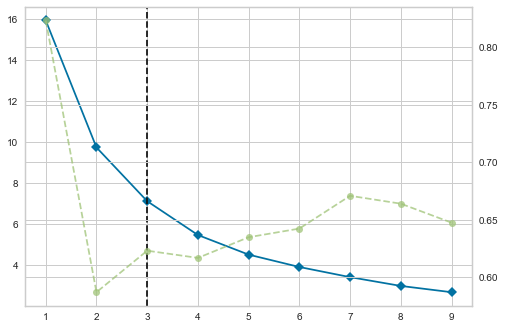

In [5]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))
visualizer.fit(data)

# 군집화

In [6]:
from sklearn.cluster import KMeans

k = 5

# 그룹 수, random_state 설정
model = KMeans(n_clusters = k, random_state = 10)

# 정규화된 데이터에 학습
model.fit(data)

# 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
df['cluster'] = model.fit_predict(data)

C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# 시각화

Gulim


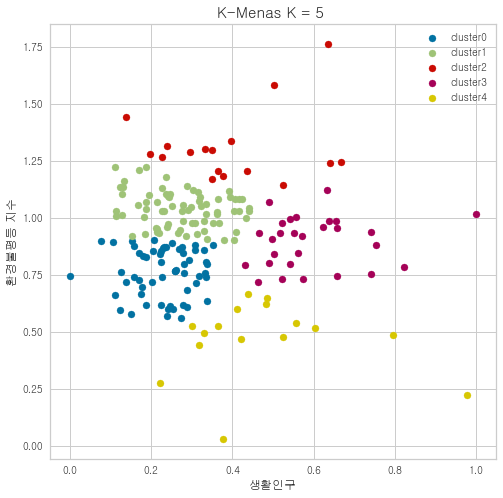

In [10]:
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, '총생활인구'], df.loc[df['cluster'] == i, '환경불평등지수'], label = 'cluster' + str(i))

plt.legend()
plt.title('K-Menas K = %d '%k , size = 15)
plt.xlabel('생활인구', size = 12)
plt.ylabel('환경불평등 지수', size = 12)
plt.show()

In [8]:
cluster_cnt = df.groupby('cluster').agg({'행정동':'count'}).reset_index()
cluster_des = df.groupby('cluster').mean().reset_index()

In [11]:
a = pd.merge(cluster_cnt,cluster_des)

In [ ]:
a

In [12]:
import dataframe_image as dfi

dfi.export(a, './image/14-2동별_K-Means_describe.png', max_cols = -1, max_rows = -1)

In [20]:
df[df.cluster==2].행정동.unique()

array(['수유2동', '등촌3동', '구의1동', '자양1동', '중곡3동', '개봉1동', '중계2·3동', '방학1동',
       '방학2동', '장안1동', '신정3동', '역촌동', '면목2동', '면목4동', '면목본동', '상봉2동',
       '중화2동'], dtype=object)

In [19]:
df[df.행정동.isin(['수유2동', '등촌3동', '구의1동', '자양1동', '중곡3동', '개봉1동', '중계2·3동', '방학1동','방학2동', '장안1동', '신정3동', '역촌동', '면목2동', '면목4동', '면목본동', '상봉2동','중화2동'])].시군구.unique()

array(['강북구', '강서구', '광진구', '구로구', '노원구', '도봉구', '동대문구', '양천구', '은평구',
       '중랑구'], dtype=object)

# 실루엣 계수

In [15]:
from sklearn.metrics import silhouette_score
 
silhouette_score(data, df['cluster'], metric='euclidean')

0.3596821200578513

In [16]:
from sklearn.metrics import silhouette_samples

# 모든 개별 데이터에 실루엣 계수값을 구함. 
score_samples = silhouette_samples(data, df['cluster'])
print('silhouette_samples( ) return 값의 shape' , score_samples.shape)

# 실루엣 계수 컬럼 추가
df['silhouette_coeff'] = score_samples

# 모든 데이터의 평균 실루엣 계수값을 구함. 
average_score = silhouette_score(data, df['cluster'])
print(' Silhouette Analysis Score:'.format(average_score))

silhouette_samples( ) return 값의 shape (192,)
 Silhouette Analysis Score:


In [38]:
df.groupby('cluster')['silhouette_coeff'].mean()

cluster
0    0.463989
1    0.486337
2    0.348976
Name: silhouette_coeff, dtype: float64